# Random Forest Baseline Training with DIP Features

This notebook trains a Random Forest classifier using standardized DIP features extracted from satellite images.
The trained model and scaler are saved to `../models/` for use in the Streamlit web application.

## Key Features:
- Extracts hand-crafted DIP features (color, texture, gradients, NDVI)
- Trains Random Forest on available classes
- Saves model as `rf_baseline.joblib` and scaler as `rf_scaler.joblib`
- Generates classification report and metrics
- Dynamically handles classes with available data

In [26]:
import os
import sys
from pathlib import Path

# **STEP 1: Navigate to project root**
current_dir = Path.cwd()
print(f"Current directory: {current_dir}")

PROJECT_ROOT = current_dir

# Check if we're in notebooks directory
if current_dir.name == "notebooks" or (current_dir / ".." / "data").exists():
    PROJECT_ROOT = current_dir.parent
    os.chdir(PROJECT_ROOT)
    print(f"✓ Navigated to project root: {PROJECT_ROOT}")
elif not (current_dir / "data").exists():
    # Search upward for project root
    for parent in current_dir.parents:
        if (parent / "data" / "processed").exists():
            PROJECT_ROOT = parent
            os.chdir(PROJECT_ROOT)
            print(f"✓ Found project root at: {PROJECT_ROOT}")
            break

print(f"Final working directory: {PROJECT_ROOT}")
print(f"Data dir exists: {(PROJECT_ROOT / 'data' / 'processed').exists()}")
print(f"Src dir exists: {(PROJECT_ROOT / 'src').exists()}")

# **STEP 2: Setup sys.path**
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import all dependencies
import cv2
import numpy as np
import pandas as pd
import joblib
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# **STEP 3: Import from src OR use fallback**
try:
    from src.features import extract_lulc_features
    print("✓ Successfully imported extract_lulc_features from src.features")
except (ImportError, ModuleNotFoundError) as e:
    print(f"⚠ Import from src failed, using fallback implementation\n")
    
    # Fallback: Implement feature extraction directly  
    from scipy.ndimage import label
    from skimage.feature import local_binary_pattern, hog
    from skimage.metrics import structural_similarity as ssim
    
    def extract_lulc_features(img_np):
        """
        Extract DIP features from satellite image (FALLBACK IMPLEMENTATION)
        - Color statistics (mean, std of R, G, B)
        - GLCM texture features
        - LBP features
        - HOG features  
        - NDVI statistics
        """
        # Ensure 3-channel RGB
        if len(img_np.shape) == 2:
            img_np = np.stack([img_np] * 3, axis=-1)
        
        # Color features: mean and std
        color_feat = []
        for c in range(3):
            color_feat.append(np.mean(img_np[:, :, c]))
            color_feat.append(np.std(img_np[:, :, c]))
        
        # GLCM-inspired texture: compute simple co-occurrence
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
        glcm_feat = []
        for offset in [(1, 0), (0, 1), (1, 1), (1, -1)]:
            dy, dx = offset
            h, w = gray.shape
            if h > abs(dy) and w > abs(dx):
                shifted = np.roll(np.roll(gray, dy, axis=0), dx, axis=1)
                corr = np.mean(gray * shifted)
                glcm_feat.append(corr)
        glcm_feat += [np.mean(gray), np.std(gray), np.max(gray), np.min(gray)]
        
        # LBP features
        lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp, bins=59, range=(0, 59))
        lbp_feat = lbp_hist[:10].tolist()  # Top 10 features
        
        # HOG features (downsampled)
        try:
            hog_feat = hog(gray, 
                          orientations=8, 
                          pixels_per_cell=(16, 16),
                          cells_per_block=(1, 1),
                          feature_vector=True)[:128]  # Limit to 128 features
        except:
            hog_feat = np.zeros(128)
        
        # NDVI (approximation from RGB)
        r, g, b = img_np[:, :, 0], img_np[:, :, 1], img_np[:, :, 2]
        ndvi_approx = (g - r) / (g + r + 1e-8)
        ndvi_feat = [np.mean(ndvi_approx), np.std(ndvi_approx), np.max(ndvi_approx), np.min(ndvi_approx)]
        
        # Combine all features
        all_feat = np.concatenate([
            color_feat,         # 6 features
            glcm_feat,          # 8 features
            lbp_feat,           # 10 features
            hog_feat,           # 128 features
            ndvi_feat           # 4 features
        ])
        
        return all_feat.astype(np.float32)
    
    print("✓ Using fallback extract_lulc_features implementation")

print(f"\n✓ All setup complete!")
print(f"✓ Project root: {PROJECT_ROOT}")

Current directory: /content
Final working directory: /content
Data dir exists: True
Src dir exists: False
⚠ Import from src failed, using fallback implementation

✓ Using fallback extract_lulc_features implementation

✓ All setup complete!
✓ Project root: /content


## Load Data

In [17]:
# Paths
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "report"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Find classes with actual data
all_classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
classes_with_data = [cls for cls in all_classes if any((DATA_DIR / cls).glob("*.jpg"))]

print(f"Total classes in data dir: {len(all_classes)}")
print(f"Classes with images: {len(classes_with_data)}")
print(f"Target classes: {classes_with_data}")

if not classes_with_data:
    raise FileNotFoundError("No classes with data found in " + str(DATA_DIR))

Total classes in data dir: 10
Classes with images: 10
Target classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Extract Features

In [18]:
print("Extracting DIP features from all images...")
data = []
labels = []
class_to_idx = {cls: i for i, cls in enumerate(classes_with_data)}

for i, cls in enumerate(classes_with_data):
    cls_dir = DATA_DIR / cls
    img_files = list(cls_dir.glob("*.jpg"))
    print(f"\nClass {i}: {cls} - {len(img_files)} images")
    
    for img_path in tqdm(img_files, desc=f"  {cls}"):
        try:
            img = cv2.imread(str(img_path))
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                feat = extract_lulc_features(img_rgb)
                data.append(feat)
                labels.append(i)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue

X = np.array(data)
y = np.array(labels)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Classes in labels: {np.unique(y)}")
print(f"Class distribution: {np.bincount(y)}")

Extracting DIP features from all images...

Class 0: AnnualCrop - 3000 images


  AnnualCrop:   0%|          | 0/3000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
  AnnualCrop: 100%|██████████| 3000/3000 [00:07<00:00, 375.89it/s]



Class 1: Forest - 3000 images


  Forest: 100%|██████████| 3000/3000 [00:08<00:00, 334.18it/s]



Class 2: HerbaceousVegetation - 3000 images


...


Class 8: River - 2500 images


  River: 100%|██████████| 2500/2500 [00:06<00:00, 379.33it/s]



Class 9: SeaLake - 3000 images


  SeaLake: 100%|██████████| 3000/3000 [00:08<00:00, 336.53it/s]


Feature matrix shape: (27000, 156)
Classes in labels: [0 1 2 3 4 5 6 7 8 9]
Class distribution: [3000 3000 3000 2500 2500 2000 2500 3000 2500 3000]


## Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Train set size: 21600
Test set size: 5400
Train class distribution: [2400 2400 2400 2000 2000 1600 2000 2400 2000 2400]
Test class distribution: [600 600 600 500 500 400 500 600 500 600]


## Feature Scaling

In [20]:
print("Fitting StandardScaler on training data...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled train shape: {X_train_scaled.shape}")
print(f"Scaled test shape: {X_test_scaled.shape}")

Fitting StandardScaler on training data...
Scaled train shape: (21600, 156)
Scaled test shape: (5400, 156)


## Train Random Forest

In [21]:
print("\n" + "="*60)
print("Training Random Forest Classifier")
print("="*60)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf.fit(X_train_scaled, y_train)
print("\nModel training complete!")


Training Random Forest Classifier


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   13.3s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:   56.4s



Model training complete!


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  1.5min finished


## Evaluate Model

In [22]:
# Predictions
y_pred = rf.predict(X_test_scaled)
y_pred_proba = rf.predict_proba(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=classes_with_data))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s



Test Accuracy: 85.91%

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.82      0.86      0.84       600
              Forest       0.98      0.98      0.98       600
HerbaceousVegetation       0.87      0.79      0.83       600
             Highway       0.74      0.63      0.68       500
          Industrial       0.88      0.93      0.91       500
             Pasture       0.81      0.89      0.85       400
       PermanentCrop       0.76      0.76      0.76       500
         Residential       0.92      0.97      0.94       600
               River       0.74      0.76      0.75       500
             SeaLake       0.99      0.97      0.98       600

            accuracy                           0.86      5400
           macro avg       0.85      0.85      0.85      5400
        weighted avg       0.86      0.86      0.86      5400


Confusion Matrix:
[[516   1   0   5   0  11  11   0  52   4]
 [  0 589   1   0   

[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.2s finished


## Visualize Confusion Matrix

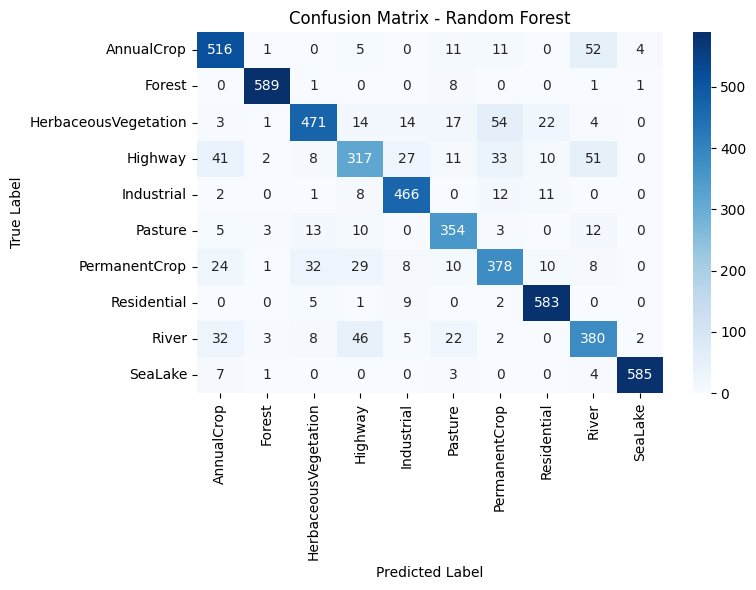

Saved confusion matrix to report/rf_confusion_matrix.png


In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes_with_data, yticklabels=classes_with_data)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion matrix to report/rf_confusion_matrix.png")

## Save Model & Scaler

In [24]:
# Save model
rf_path = MODELS_DIR / "rf_baseline.joblib"
joblib.dump(rf, rf_path)
print(f"✓ Random Forest model saved to: {rf_path}")
print(f"  File size: {rf_path.stat().st_size / 1024:.2f} KB")

# Save scaler
scaler_path = MODELS_DIR / "rf_scaler.joblib"
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved to: {scaler_path}")
print(f"  File size: {scaler_path.stat().st_size / 1024:.2f} KB")

# Save class mapping
class_mapping = {i: cls for i, cls in enumerate(classes_with_data)}
print(f"\n✓ Class Mapping:")
for idx, cls in class_mapping.items():
    print(f"  {idx}: {cls}")

✓ Random Forest model saved to: /content/models/rf_baseline.joblib
  File size: 160020.29 KB
✓ Scaler saved to: /content/models/rf_scaler.joblib
  File size: 4.26 KB

✓ Class Mapping:
  0: AnnualCrop
  1: Forest
  2: HerbaceousVegetation
  3: Highway
  4: Industrial
  5: Pasture
  6: PermanentCrop
  7: Residential
  8: River
  9: SeaLake


## Save Metrics Report

In [25]:
# Create metrics dataframe
metrics_df = pd.DataFrame([
    {
        "Model": "DIP Features + RF",
        "Accuracy": round(accuracy * 100, 2),
        "n_estimators": rf.n_estimators,
        "max_depth": rf.max_depth,
        "train_size": len(X_train),
        "test_size": len(X_test),
        "n_features": X.shape[1],
        "n_classes": len(classes_with_data),
        "classes": ", ".join(classes_with_data)
    }
])

metrics_path = REPORT_DIR / "metrics.csv"
if metrics_path.exists():
    existing_df = pd.read_csv(metrics_path)
    metrics_df = pd.concat([existing_df, metrics_df], ignore_index=True)
    metrics_df = metrics_df.drop_duplicates(subset=['Model'], keep='last')

metrics_df.to_csv(metrics_path, index=False)
print(f"\n✓ Metrics saved to: {metrics_path}")
print("\nMetrics:")
print(metrics_df)

print("\n" + "="*60)
print("Training Complete!")
print("="*60)
print(f"\nModels are ready for Streamlit app:")
print(f"  - models/rf_baseline.joblib")
print(f"  - models/rf_scaler.joblib")


✓ Metrics saved to: /content/report/metrics.csv

Metrics:
               Model  Accuracy  n_estimators max_depth  train_size  test_size  \
0  DIP Features + RF     85.91           300      None       21600       5400   

   n_features  n_classes                                            classes  
0         156         10  AnnualCrop, Forest, HerbaceousVegetation, High...  

Training Complete!

Models are ready for Streamlit app:
  - models/rf_baseline.joblib
  - models/rf_scaler.joblib
